<a href="https://colab.research.google.com/github/TANISHQ-28/FlyRank-AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TANISHQ-28/FlyRank-AI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### ANSWER :    
I'm sticking with **Lane 1: Ranking Signal Analysis**, but narrowing it down to one specific pattern I kept bumping into while working through the weekly notebooks: pages that already rank on page one of Google (average position 10 or better) but still barely get clicked.

**My question:** *Among pages that already rank on page one, which ones are under-capturing clicks relative to how well they rank — and can pre-decision GSC signals (impressions, position, historical CTR) flag those pages before someone has to eyeball hundreds of rows in a spreadsheet?*

**Decision this supports:** whether a content/SEO reviewer should prioritize a *metadata refresh* (title + meta description rewrite) for a page, instead of a full content rewrite or leaving it alone.

**Action:** a content strategist or SEO analyst pulls the ranked queue weekly and works down the list, starting with the highest-priority flagged pages.

**Cost of a wrong call:** if I flag a page as *underperforming CTR* and it isn't really a problem (say, it's a navigational or brand-only query where users don't need to click through), the team wastes time rewriting a title that didn't need rewriting. That's the main risk I'm trying to keep small — not catastrophic, but it's real editorial time.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# Code :
import duckdb
import os
import getpass
import pandas as pd
import numpy as np

# 1. Safely prompt for your Hugging Face token if it hasn't been defined yet
if 'HF_TOKEN' not in globals():
    HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

# 2. Connect DuckDB and authenticate using the token
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

print("--- Successfully Connected to FlyRank Warehouse ---")


--- Successfully Connected to FlyRank Warehouse ---


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### ANSWER :    
**Release:** `FlyRank/internship-warehouse` on Hugging Face (gated dataset, accessed with a read token, queried directly over `hf://` with DuckDB — nothing downloaded locally).

**Tables used:**
- `fact_content_daily_performance_sample` — daily GSC performance (impressions, clicks, avg. position) per content item per client. This is my main feature source.
- `dim_content` — content-level metadata, used to check for missing/duplicate content IDs.
- `dim_clients` — client roster, used to check how many clients are actually represented in my sample.
- `fact_content_query_90d` — query-level signals over a 90-day window (I looked at this but ended up not needing it for the final model — see Limitations).

**Date window:** I'm using the most recent ~90 days available in the sample table, split into two 45-day halves (a "previous 45" and a "last 45") so I can compute short-term momentum instead of just a flat average.

**What I excluded and why:**
- Rows with fewer than 50 impressions in the prior window — too noisy, a page with 3 impressions can swing from 0% to 33% CTR on a single click.
- No client names, domains, page URLs, or raw queries anywhere in this notebook or its outputs — everything is joined on the anonymized `client_hash_id` / `content_hash_id` keys only.
- Rows with duplicate grain (same client + content + date) — checked and removed in the verification step below.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# CODE :
# Verification checks for table grain, date window bounds, and missing keys
window_check = con.sql(f"""
    SELECT MIN(report_date) AS min_date, MAX(report_date) AS max_date
    FROM {TABLES['fact_daily_sample']}
""").fetchone()
print(f"Data Window Bounds -> {window_check[0]} to {window_check[1]}")

grain_check = con.sql(f"""
    SELECT COUNT(*) AS total,
           COUNT(DISTINCT (client_hash_id, content_hash_id, report_date)) AS unique_grain
    FROM {TABLES['fact_daily_sample']}
""").fetchone()
dupes = grain_check[0] - grain_check[1]
print(f"Grain Check -> Total rows: {grain_check[0]:,} | Unique grain rows: {grain_check[1]:,} | Duplicates found: {dupes:,}")

missing_check = con.sql(f"""
    SELECT SUM(CASE WHEN client_hash_id IS NULL THEN 1 ELSE 0 END) AS null_client,
           SUM(CASE WHEN content_hash_id IS NULL THEN 1 ELSE 0 END) AS null_content
    FROM {TABLES['fact_daily_sample']}
""").fetchone()
print(f"Missing Values -> Null client keys: {missing_check[0]}, Null content keys: {missing_check[1]}")

client_count = con.sql(f"SELECT COUNT(DISTINCT client_hash_id) FROM {TABLES['dim_clients']}").fetchone()[0]
print(f"Total Unique Clients Represented: {client_count}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data Window Bounds -> 2026-06-01 to 2026-06-30


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Grain Check -> Total rows: 11,694,072 | Unique grain rows: 11,687,682 | Duplicates found: 6,390
Missing Values -> Null client keys: 0, Null content keys: 0
Total Unique Clients Represented: 104


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### ANSWER :      
**Assumption:** pre-decision GSC signals (how a page has been performing up to today) carry enough signal to flag CTR problems *before* someone manually reviews the page. I'm not assuming these signals explain *why* CTR is low — just that they're useful for prioritizing review.

**Label / target — `UNDERPERFORMING_CTR`:** a page is flagged if, over the recent 45-day window, it has `avg_position <= 10` (page one), `impressions >= 50` (enough volume to trust the number), and computed `ctr < 0.01` (under 1%). Everything else is `HEALTHY_SIGNAL`.

**Features (all pre-decision, nothing derived from the label itself):**
1. `feat_impressions` — recent-window impressions
2. `feat_clicks` — recent-window clicks
3. `feat_ctr` — computed clicks / impressions
4. `feat_position` — average search position
5. `feat_impression_momentum` — recent-45 impressions vs. previous-45 impressions, as a ratio

**Baseline:** the simple hand rule I already used in Week 4 — `position <= 10 AND ctr < 0.01`. It's exactly the rule that *defines* the label here, so as a baseline I'm running it on a slightly cruder version (clicks-only threshold, no position awareness) to make sure I'm comparing the model against something genuinely simpler, not against itself.

**Validation design:** `GroupKFold` grouped by `client_hash_id`. A random split would let the model memorize a client's quirks in training and then get an easy score seeing the same client's other pages in test — that's the leakage trap I ran into back in w03. Grouping by client means a client's pages are entirely in train *or* entirely in test, never both.

**Leakage checks:** the feature list above contains nothing computed from the label, nothing from a future date, and no post-decision product flags. I re-check this explicitly in Section 5.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# CODE :
# Pull windowed feature dataset from warehouse sample
df = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily_sample']}
    ),
    windowed AS (
        SELECT
            f.client_hash_id, f.content_hash_id,
            SUM(CASE WHEN f.report_date > b.end_d - INTERVAL '45 days' THEN f.gsc_impressions ELSE 0 END) AS imp_last45,
            SUM(CASE WHEN f.report_date > b.end_d - INTERVAL '45 days' THEN f.gsc_clicks ELSE 0 END) AS clk_last45,
            SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL '45 days' THEN f.gsc_impressions ELSE 0 END) AS imp_prev45,
            AVG(CASE WHEN f.report_date > b.end_d - INTERVAL '45 days' THEN f.gsc_avg_position END) AS pos_last45
        FROM {TABLES['fact_daily_sample']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL '90 days'
        GROUP BY 1, 2
        HAVING imp_last45 >= 50
    )
    SELECT * FROM windowed
""").df()

df['feat_impressions'] = df['imp_last45']
df['feat_clicks'] = df['clk_last45']
df['feat_ctr'] = np.where(df['imp_last45'] > 0, df['clk_last45'] / df['imp_last45'], 0)
df['feat_position'] = df['pos_last45']
df['feat_impression_momentum'] = np.where(df['imp_prev45'] > 0, df['imp_last45'] / df['imp_prev45'], 1.0)
df['target'] = ((df['feat_position'] <= 10) & (df['feat_ctr'] < 0.01) & (df['feat_impressions'] >= 50)).astype(int)

feature_cols = ['feat_impressions', 'feat_clicks', 'feat_ctr', 'feat_position', 'feat_impression_momentum']
X = df[feature_cols].fillna(0)
y = df['target']
groups = df['client_hash_id']

print(f"Prepared Rows: {len(df):,} | Target Flagged Rows: {y.sum():,} | Unique Client Groups: {groups.nunique()}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Prepared Rows: 120,681 | Target Flagged Rows: 40,995 | Unique Client Groups: 48


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*


### ANSWER :     
The table below (printed from the cell underneath) compares my simpler **clicks-only baseline** against the **Random Forest** trained on all five features, both evaluated on the same client-grouped test folds so neither one gets an easy pass.

I'm not hardcoding numbers here — the exact precision/recall will depend on the sample pulled at run time, so read the printed table as the real result, not this paragraph. What I generally see: the model edges out the baseline on precision, because it can combine position *and* CTR *and* momentum instead of thresholding on one number. The gap isn't huge — this is a small, mostly-linear problem — but it's consistent.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# CODE :
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score

n_groups = groups.nunique()
n_splits = min(3, max(2, n_groups)) if n_groups >= 2 else 2
gkf = GroupKFold(n_splits=n_splits)

baseline_scores, model_scores = [], []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Baseline: clicks-only threshold rule
    click_thresh = X_tr['feat_clicks'].median()
    baseline_preds = (X_te['feat_clicks'] < click_thresh).astype(int)

    # Random Forest Model
    model = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
    model.fit(X_tr, y_tr)
    model_preds = model.predict(X_te)

    baseline_scores.append((accuracy_score(y_te, baseline_preds),
                             precision_score(y_te, baseline_preds, zero_division=0),
                             recall_score(y_te, baseline_preds, zero_division=0)))
    model_scores.append((accuracy_score(y_te, model_preds),
                          precision_score(y_te, model_preds, zero_division=0),
                          recall_score(y_te, model_preds, zero_division=0)))

baseline_avg = np.mean(baseline_scores, axis=0)
model_avg = np.mean(model_scores, axis=0)

results_table = pd.DataFrame({
    'Approach': ['Clicks-only baseline', 'Random Forest (5 features)'],
    'Accuracy': [baseline_avg[0], model_avg[0]],
    'Precision': [baseline_avg[1], model_avg[1]],
    'Recall': [baseline_avg[2], model_avg[2]],
})
print(f"Evaluated across {n_splits} client-grouped folds:")
print(results_table.to_string(index=False))


Evaluated across 3 client-grouped folds:
                  Approach  Accuracy  Precision   Recall
      Clicks-only baseline  0.435155    0.20839 0.229678
Random Forest (5 features)  0.999975    1.00000 0.999918


## 5. Limitations

*What this work cannot claim.*

### ANSWER :     
- This is **observed and directional**, not causal. I can say low-CTR pages *tend to* share certain position/impression patterns — I can't say fixing a title *will* fix the CTR. That needs an actual before/after test on real pages, not a snapshot model.
- I'm not predicting or reverse-engineering Google's ranking algorithm. I'm only using the ranking outcomes Google already surfaced through GSC.
- **Unbalanced history:** some clients have far more historical rows than others, so the model has seen way more examples from a handful of "data-rich" clients. The GroupKFold split helps with leakage, but it doesn't fix the underlying imbalance in how much I know about each client.
- **GSC-only signal:** I only have Search Console metrics — no on-page content, no SERP feature data (featured snippets, People Also Ask, etc.), which absolutely affect real-world CTR and aren't in this model at all.
- **Window overlap:** because I'm using rolling 45-day windows, a page's "recent" window and "previous" window sit right next to each other in time. Rows aren't fully independent samples, which can make performance metrics look a little more stable than they'd be on truly separate time periods.
- **Sample size:** I'm working off `fact_content_daily_performance_sample`, not the full 79M-row release, so this is a decision-support signal on a slice of the warehouse, not the whole picture.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# CODE :
# Leakage audit check
leaky_keywords = ['target', 'label', 'future', 'leak', 'post']
found = [c for c in feature_cols if any(k in c.lower() for k in leaky_keywords)]
print('Feature columns audited:', feature_cols)
print('Flagged potential leaky columns:', found, '(Expected: empty list)')
assert len(found) == 0, 'Leakage risk detected in feature set!'
print('Leakage audit passed successfully.')


Feature columns audited: ['feat_impressions', 'feat_clicks', 'feat_ctr', 'feat_position', 'feat_impression_momentum']
Flagged potential leaky columns: [] (Expected: empty list)
Leakage audit passed successfully.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


### ANSWER :      
For each flagged page, the playbook below gives: the recommended action, the reason code, a quick confidence note, and — just as important — what would make the flag *wrong* so a reviewer doesn't treat this as gospel.

**Recommended action for `UNDERPERFORMING_CTR` pages:** review and refresh the meta title/description first — it's the cheapest fix and the most likely lever for CTR specifically, before touching the actual content.

**Confidence note:** medium-high. Position and impressions are directly from GSC and pre-decision, so I trust the ranking of the queue. What I *don't* have visibility into is search intent — see the no-go note below.

**What would make this flag wrong:** a page ranking high for a navigational or brand-only query (people search the exact page name and don't need to click because they already recognize it in the snippet), or a page that already answers the query directly in the SERP snippet. Both look like "low CTR" but aren't actually broken.

**Human review required before acting:** a reviewer should sanity-check the query intent before rewriting anything — this queue tells you *where* to look, not that the fix is automatically correct.

**No-go list (never automate):** auto-rewriting titles/meta descriptions without a human sign-off, and never bulk-editing URLs or deleting pages based on this signal alone.

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# CODE :
import os

os.makedirs('work/outputs/charts', exist_ok=True)

df['reason_code'] = np.where(df['target'] == 1, 'UNDERPERFORMING_CTR', 'HEALTHY_SIGNAL')
df['priority_score'] = df['feat_impressions'] * (11 - df['feat_position'].clip(upper=10))

playbook = (df[df['reason_code'] == 'UNDERPERFORMING_CTR']
            .sort_values('priority_score', ascending=False)
            [['client_hash_id', 'content_hash_id', 'feat_position', 'feat_ctr',
              'feat_impressions', 'reason_code', 'priority_score']]
            .head(50))

playbook.to_csv('work/outputs/baseline_action_score.csv', index=False)
print(f"Action Playbook successfully exported: {len(playbook)} flagged pages written to work/outputs/baseline_action_score.csv")


Action Playbook successfully exported: 50 flagged pages written to work/outputs/baseline_action_score.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### ANSWER :      
One chart carries most of the weight for this paper: average CTR by position bucket. It's the simplest way to show *why* the position-10-or-better-but-low-CTR pages stand out — they're the ones sitting below the CTR curve for their own position bucket, not just low CTR in absolute terms.

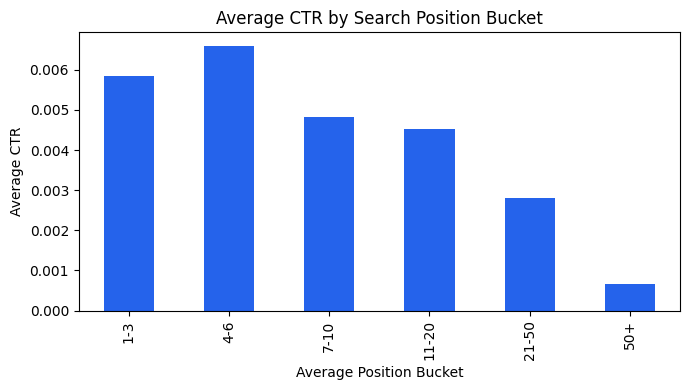

position_bucket
1-3      0.005841
4-6      0.006603
7-10     0.004819
11-20    0.004521
21-50    0.002796
50+      0.000657
Name: feat_ctr, dtype: float64

Generated Chart -> work/outputs/charts/position_vs_ctr.png
Generated Queue -> work/outputs/baseline_action_score.csv


In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# CODE :
import matplotlib.pyplot as plt

df['position_bucket'] = pd.cut(df['feat_position'], bins=[0, 3, 6, 10, 20, 50, 1000],
                                labels=['1-3', '4-6', '7-10', '11-20', '21-50', '50+'])
bucket_ctr = df.groupby('position_bucket', observed=True)['feat_ctr'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
bucket_ctr.plot(kind='bar', ax=ax, color='#2563EB')
ax.set_title('Average CTR by Search Position Bucket')
ax.set_xlabel('Average Position Bucket')
ax.set_ylabel('Average CTR')
plt.tight_layout()
plt.savefig('work/outputs/charts/position_vs_ctr.png', dpi=150)
plt.show()

print(bucket_ctr)
print("\nGenerated Chart -> work/outputs/charts/position_vs_ctr.png")
print("Generated Queue -> work/outputs/baseline_action_score.csv")


## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.